In [1]:
# 1. Import all necessary libraries
import pandas as pd
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.tree import export_graphviz
from IPython.display import Image  
import pydotplus
import io
import os

graphviz_path = "D:\Programs\Graphviz\bin\dot.exe"
os.environ["PATH"] += os.pathsep + graphviz_path

In [2]:
# 2. Load the dataset
url = 'https://raw.githubusercontent.com/luelhagos/Play-Tennis-Implementation-Using-Sklearn-Decision-Tree-Algorithm/master/Play%20Tennis.csv'
df = pd.read_csv(url)


In [3]:
# 3. Encode the categorical data into numbers
df_encoded = df.apply(preprocessing.LabelEncoder().fit_transform)

In [4]:
# 4. Separate features (X) and target (y)
feature_cols = ['Outlook', 'Temprature', 'Humidity', 'Wind']
X = df_encoded[feature_cols]
y = df_encoded.Play_Tennis

In [5]:
# 5. Split data into training and testing sets for reproducible results
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

In [6]:
# 6. Train the Decision Tree model
# [cite_start]Using 'entropy' to measure the quality of a split [cite: 77]
classifier = DecisionTreeClassifier(criterion="entropy", random_state=100)
classifier.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=100)

In [7]:
# 7. Make predictions on the test data
y_pred = classifier.predict(X_test)

In [8]:
# 8. Print the evaluation results
print("--- Model Evaluation ---")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

--- Model Evaluation ---
Accuracy: 0.6

Confusion Matrix:
 [[1 1]
 [1 2]]

Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.50      0.50         2
           1       0.67      0.67      0.67         3

    accuracy                           0.60         5
   macro avg       0.58      0.58      0.58         5
weighted avg       0.60      0.60      0.60         5



In [9]:
# 9. Create the decision tree visualization
dot_data = io.StringIO()
export_graphviz(classifier, out_file=dot_data,  
                filled=True, rounded=True,
                special_characters=True, feature_names=feature_cols, class_names=['No', 'Yes'])

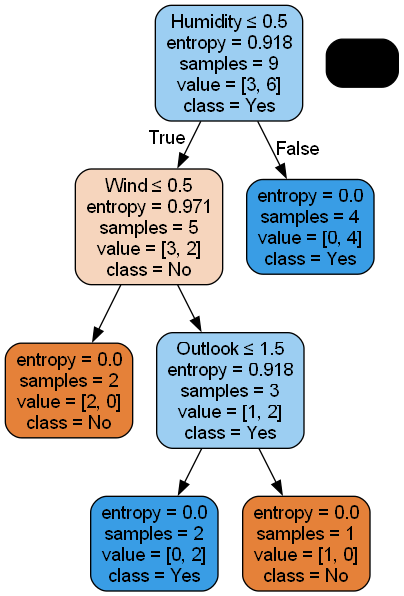

In [10]:
# 10. Display the tree
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())  
Image(graph.create_png())